# LO4 - API with Alpha Vantage

***

There are multiple ways to import data from the 'Alpha Vantage' API. <br>


First, you'll need to pip install the alpha-vantage module.
<br>
**pip install alpha-vantage**.
<br> <br>
Then, you need to go to https://www.alphavantage.co/ and click on "Get Your Free API Key". Save it, as you will need to replace all "INSERT-YOUR-API-KEY-HERE" strings you see within the code presented in this document.

Then, import the usual modules for retrieving and manipulating financial data in Python:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
! pip install alpha-vantage


From the module you just installed, you need to import TimeSeries.

In [ ]:
from alpha_vantage.timeseries import TimeSeries

Then, with the following line, designate your API key, as well as the format in which you would like to retrieve the data. In our case, this will be the 'pandas' module.

In [ ]:
demo = 'THOZXU8VMNLZ8JLS' #YOUR API KEY HERE
alpha = pd.read_csv(
    'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=MSFT&apikey=' + demo + '&datatype=csv')
alpha.head()
#only 5 minutes is the fastest
#TIME intervals are:
    #INTRADAY , DAILY , DAILY_ADJUSTED , WEEKLY , MONTHLY , YEARLY
    #need to pay for intraday
#LH1QNQRB8AUG767R replace with DEMO

,timestamp,open,high,low,close,volume
0,2026-01-27,473.700,482.87,473.16,480.58,29088664
1,2026-01-26,465.305,474.25,462.00,470.28,29291235
2,2026-01-23,451.870,471.10,450.53,465.95,38000159
3,2026-01-22,447.620,452.84,444.70,451.14,25349378
4,2026-01-21,452.595,452.69,438.68,444.11,37980510


In [ ]:
    #alpha1 = alpha[::1]
alpha1 = pd.read_csv('https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=TSLA&apikey=' + demo + '&datatype=csv')
alpha1.head()
# ::-1 will flip the dataframe

,timestamp,open,high,low,close,volume
0,2026-01-27,437.410,437.52,430.6900,430.90,37321502
1,2026-01-26,445.000,445.04,434.2800,435.20,49397415
2,2026-01-23,447.425,452.43,444.0400,449.06,56771364
3,2026-01-22,435.160,449.50,432.6300,449.36,71546729
4,2026-01-21,421.660,438.20,419.6201,431.44,68123987


In [ ]:
alpha1.head(10)

,timestamp,open,high,low,close,volume
0,2026-01-27,437.410,437.520,430.6900,430.90,37321502
1,2026-01-26,445.000,445.040,434.2800,435.20,49397415
2,2026-01-23,447.425,452.430,444.0400,449.06,56771364
3,2026-01-22,435.160,449.500,432.6300,449.36,71546729
4,2026-01-21,421.660,438.200,419.6201,431.44,68123987
5,2026-01-20,429.360,430.725,417.4400,419.25,62208186
6,2026-01-16,439.500,447.250,435.2601,437.50,60220551
7,2026-01-15,441.125,445.360,437.6500,438.57,49465813
8,2026-01-14,442.810,443.910,434.2200,439.20,57259500
9,2026-01-13,450.200,451.810,443.9500,447.20,53719214


In [ ]:
alpha1.set_index('timestamp', inplace = True)
alpha1.head(10)

,open,high,low,close,volume
timestamp,,,,,
2026-01-27,437.410,437.520,430.6900,430.90,37321502
2026-01-26,445.000,445.040,434.2800,435.20,49397415
2026-01-23,447.425,452.430,444.0400,449.06,56771364
2026-01-22,435.160,449.500,432.6300,449.36,71546729
2026-01-21,421.660,438.200,419.6201,431.44,68123987
2026-01-20,429.360,430.725,417.4400,419.25,62208186
2026-01-16,439.500,447.250,435.2601,437.50,60220551
2026-01-15,441.125,445.360,437.6500,438.57,49465813
2026-01-14,442.810,443.910,434.2200,439.20,57259500


In [ ]:
list = alpha1.index.tolist()
list[0:20]

['2026-01-27',
 '2026-01-26',
 '2026-01-23',
 '2026-01-22',
 '2026-01-21',
 '2026-01-20',
 '2026-01-16',
 '2026-01-15',
 '2026-01-14',
 '2026-01-13',
 '2026-01-12',
 '2026-01-09',
 '2026-01-08',
 '2026-01-07',
 '2026-01-06',
 '2026-01-05',
 '2026-01-02',
 '2025-12-31',
 '2025-12-30',
 '2025-12-29']

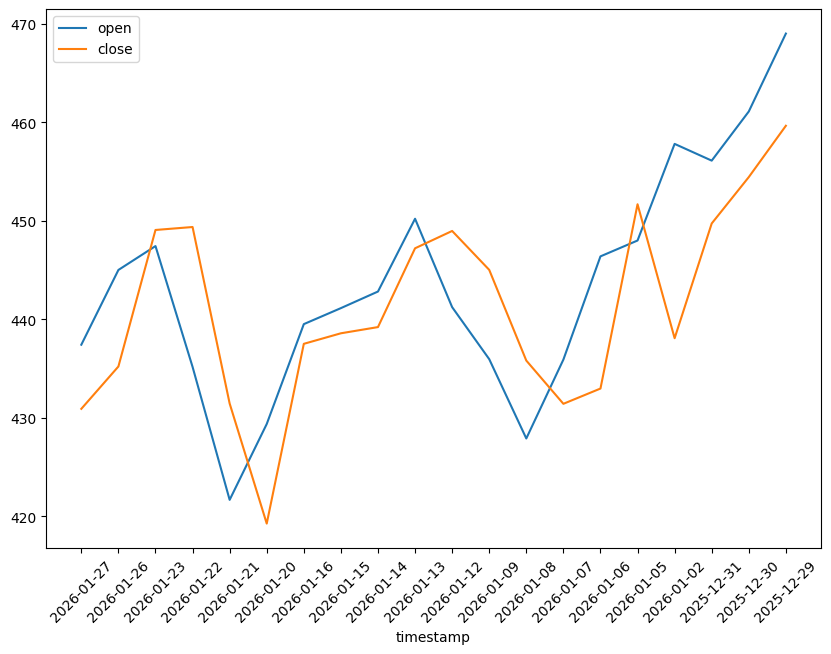

In [ ]:
alpha1[['open', 'close']].head(20).plot(figsize = (10,7))
plt.xticks(np.arange(0,20),list[0:20])
plt.xticks(rotation = 45)
plt.show()

In [ ]:
ts = TimeSeries(key = 'LH1QNQRB8AUG767R', output_format='pandas')


Notice the API call returns both stock data as well as metadata

Then, apply the **.get_daily_adjusted()** method to obtain the adjusted closing prices for the designated stock.


In [ ]:
PG_av = pd.read_csv('https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=TSLA&apikey=' + demo + '&datatype=csv')
PG_av.head()


,timestamp,open,high,low,close,volume
0,2026-01-27,437.410,437.52,430.6900,430.90,37321502
1,2026-01-26,445.000,445.04,434.2800,435.20,49397415
2,2026-01-23,447.425,452.43,444.0400,449.06,56771364
3,2026-01-22,435.160,449.50,432.6300,449.36,71546729
4,2026-01-21,421.660,438.20,419.6201,431.44,68123987
